# Machine Learning Assessment Project- Classification

## **Multi-Class Classification Approach to Student Academic Success Prediction**

Si Tang Lin

Student id: 476912


**Check README.txt**


**Environment**
- Python 3.10
- Tested on Python 3.10.12

**Setup**
- python3.10 -m venv venv
- source venv/bin/activate  (Linux/Mac)
- venv\Scripts\activate     (Windows)


## 1. Import Libraries

**Check requirements.txt if needed**

In [3]:
## Load libraries& Set seeds
# Reproducibility
import numpy as np
np.random.seed(42)

# Libraries
import os
import math
import pandas as pd
from scipy.stats import (
    chi2_contingency,
    pointbiserialr,
    ttest_ind,
    kruskal
)
from scipy.stats.mstats import winsorize

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    PowerTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import category_encoders as ce

from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    SelectFromModel,
    SequentialFeatureSelector
)
from sklearn.decomposition import PCA

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.utils.class_weight import compute_sample_weight
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_fscore_support,
    make_scorer
)
import sklearn



## 2. Load & Inspect Data
**Dataset: Predict Students' Dropout and Academic Success (UCI ML Repo)**

##### Key Details
- Source: UCI Machine Learning Repository
- URL: https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success


- Number of instances: 4424

- Number of features: 36

- Feature types: Integer

- Task type: Classification

- Subject area: Social Science



In [4]:
## Load and inspect data

student_dropout = pd.read_csv("data/students dropout_data.csv")

print(student_dropout.head())
print(student_dropout.info())
print(student_dropout.describe())
print("Missing values:\n", student_dropout.isnull().sum())

# No missing value in our dataset
# All variables were cast to integers for processing.
# To ensure correct treatment of variable types (numeric, ordinal, nominal)
# We restore each column to its appropriate original data type.


   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance\t  Previous qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1                       1   
4                             0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2                         

#### **Problem Statement**

This project addresses a **multi-class classification problem** which aimed at predicting student academic outcomes.
The target variable consists of three classes: Dropout, Enrolled, and Graduate.

The objective of this project is to systematically compare multiple classification models and imbalance-handling techniques, using appropriate evaluation metrics, in order to identify a model that presents well and effectively captures dropout cases.

Ethical issues such as data bias, class imbalance, and model misuse were considered, and provided in Chapter 14.


## 3. Train, Validation and Test data split

**Split the datat into training, validation and testing data sets**
- Train the models and Tune hyperparameters on the training set
- Access true generalization performance using the validation set
- Evaluate final performance on an unseen test set

**1. Reserve 20% of the data as a test set to evaluate**

**2. Validation set is 15% of the training data**


In [5]:
## 1. Train/ Test split

X_train, X_test, y_train, y_test = train_test_split(
    student_dropout.drop(columns="Target"),
    student_dropout["Target"],
    test_size=0.2,
    stratify=student_dropout["Target"],
    random_state=42
)

print("Successfully split train and test")

Successfully split train and test


In [6]:
## 2. Train and Validation split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,         
    y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print("Train and Validation split done")


(3008, 36)
(531, 36)
(885, 36)
Train and Validation split done


## 4. Variable Typing

**Assign variable types to ensure each feature is processed correctly during preprocessing.**

**"Predicted labels were mapped back to their original categorical representations to ensure interpretability and to support fair and responsible model evaluation" (Molnar, 2022; Mitchell et al., 2019).**

**Main Purpose:**
- 1. Selecting appropriate encoding strategies
- 2. Applying scaling only to numerical variables

In [7]:
## Assigning data type

nominal_cols = ["Marital status", "Application mode", "Course", "Nacionality",
                "Mother's occupation", "Father's occupation"]

ordinal_cols = ["Application order", "Previous qualification",
                "Mother's qualification", "Father's qualification"]

numeric_cols = [
    "Previous qualification (grade)", "Admission grade", "Age at enrollment",
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

binary_cols = [
    "Displaced", "Daytime/evening attendance", "Educational special needs",
    "Debtor", "Tuition fees up to date", "Gender",
    "Scholarship holder", "International"
]

In [8]:
## Restore to original data type

def assign_variable_types(df):
    df = df.copy()
    df.columns = df.columns.str.strip()

    # nominal + ordinal + binary → category
    for c in nominal_cols + ordinal_cols + binary_cols:
        if c in df.columns:
            df[c] = df[c].replace(r'^\s*$', np.nan, regex=True)
            df[c] = df[c].astype('category')

    # numeric → numeric
    for c in numeric_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    return df

In [9]:
## Fit and Transform

X_train  = assign_variable_types(X_train)
X_val = assign_variable_types(X_val)

## 5. Near Zero Variance

**NZV features provide little to no predictive power and may negatively affect model performance.**

**Identify such features based on:**
- 1. Frequency ratio: dominance of the most common value

- 2. Unique ratio: proportion of unique values relative to sample size

In [10]:
## 1. Define NZV function 
def near_zero_var(df, freq_cut=95/5, unique_cut=10):

    results = []
    for col in df.columns:
        counts = df[col].value_counts()

        if len(counts) > 1:
            freq_ratio = counts.iloc[0] / counts.iloc[1]
        else:
            freq_ratio = float('inf') 

        unique_ratio = len(counts) / len(df)

        high_freq_ratio = int(freq_ratio > freq_cut)
        low_unique_ratio = int(unique_ratio < unique_cut)

        results.append({
            'variable': col,
            'freq_ratio': freq_ratio,
            'unique_ratio': unique_ratio,
            'high_freq_ratio': high_freq_ratio,
            'low_unique_ratio': low_unique_ratio
        })
    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(by=['freq_ratio', 'unique_ratio'], ascending=[False, True])

    return results_df

In [11]:
## Apply to the dataset
X_train_nzv = near_zero_var(X_train, freq_cut=97/3, unique_cut=10)
X_train_nzv[(X_train_nzv['low_unique_ratio'] == 1) & (X_train_nzv['high_freq_ratio'] == 1)]

,variable,freq_ratio,unique_ratio,high_freq_ratio,low_unique_ratio
7,Nacionality,127.608696,0.005652,1,1
14,Educational special needs,87.470588,0.000665,1,1
20,International,40.205479,0.000665,1,1
21,Curricular units 1st sem (credited),39.621212,0.006981,1,1
27,Curricular units 2nd sem (credited),36.273973,0.006316,1,1


In [12]:
## 2. Chi-square method to check if we can drop the variable

chi2_results = []

# : Near-zero variance variables
nzv_vars = [
    'Nacionality',
    'Educational special needs',
    'Curricular units 1st sem (credited)',
    'International',
    'Curricular units 2nd sem (credited)'
]

# : Multi-class Chi-square on NZV variables
for col in nzv_vars:
    
    if col not in X_train.columns:
        continue
    
    table = pd.crosstab(X_train[col], y_train)

    if table.shape[0] < 2:
        chi2_results.append([col, None, None])
        continue
    
    chi2, p, dof, expected = chi2_contingency(table)
    chi2_results.append([col, p, dof])

chi2_df = pd.DataFrame(chi2_results, columns=['variable', 'p_value', 'dof'])
print("\n= Chi-square results on NZV variables (multi-class Target) =")
print(chi2_df.sort_values('p_value'))


# Null Hypothesis: There is no statistically significant relationship between the two variables.
# There is a significant relationship between Curricular units 1st sem (credited), Curricular units 2nd sem (credited) and target variable, we proceed with further analysis on this variable.
# The relationship between Nacionality, International, Educational special needs and the target is not statistically significant.
### We drop "Nacionality", "International", "Educational special need"


= Chi-square results on NZV variables (multi-class Target) =
                              variable   p_value  dof
3                        International  0.152873    2
2  Curricular units 1st sem (credited)  0.281540   40
0                          Nacionality  0.330917   32
4  Curricular units 2nd sem (credited)  0.638199   36
1            Educational special needs  0.788862    2


In [13]:
## Initial Decisions on Near-Zero Variance

DROP_COLS_NZV = [
    'Nacionality',
    'International',
    'Educational special needs'
]
def drop_nzv_features(df):
    df = df.copy()
    df = df.drop(columns=[c for c in DROP_COLS_NZV if c in df.columns])
    return df

In [14]:
## Fit and Transform

X_train  = drop_nzv_features(X_train)
X_val = drop_nzv_features(X_val)

## 6. EDA& Feature Inspection

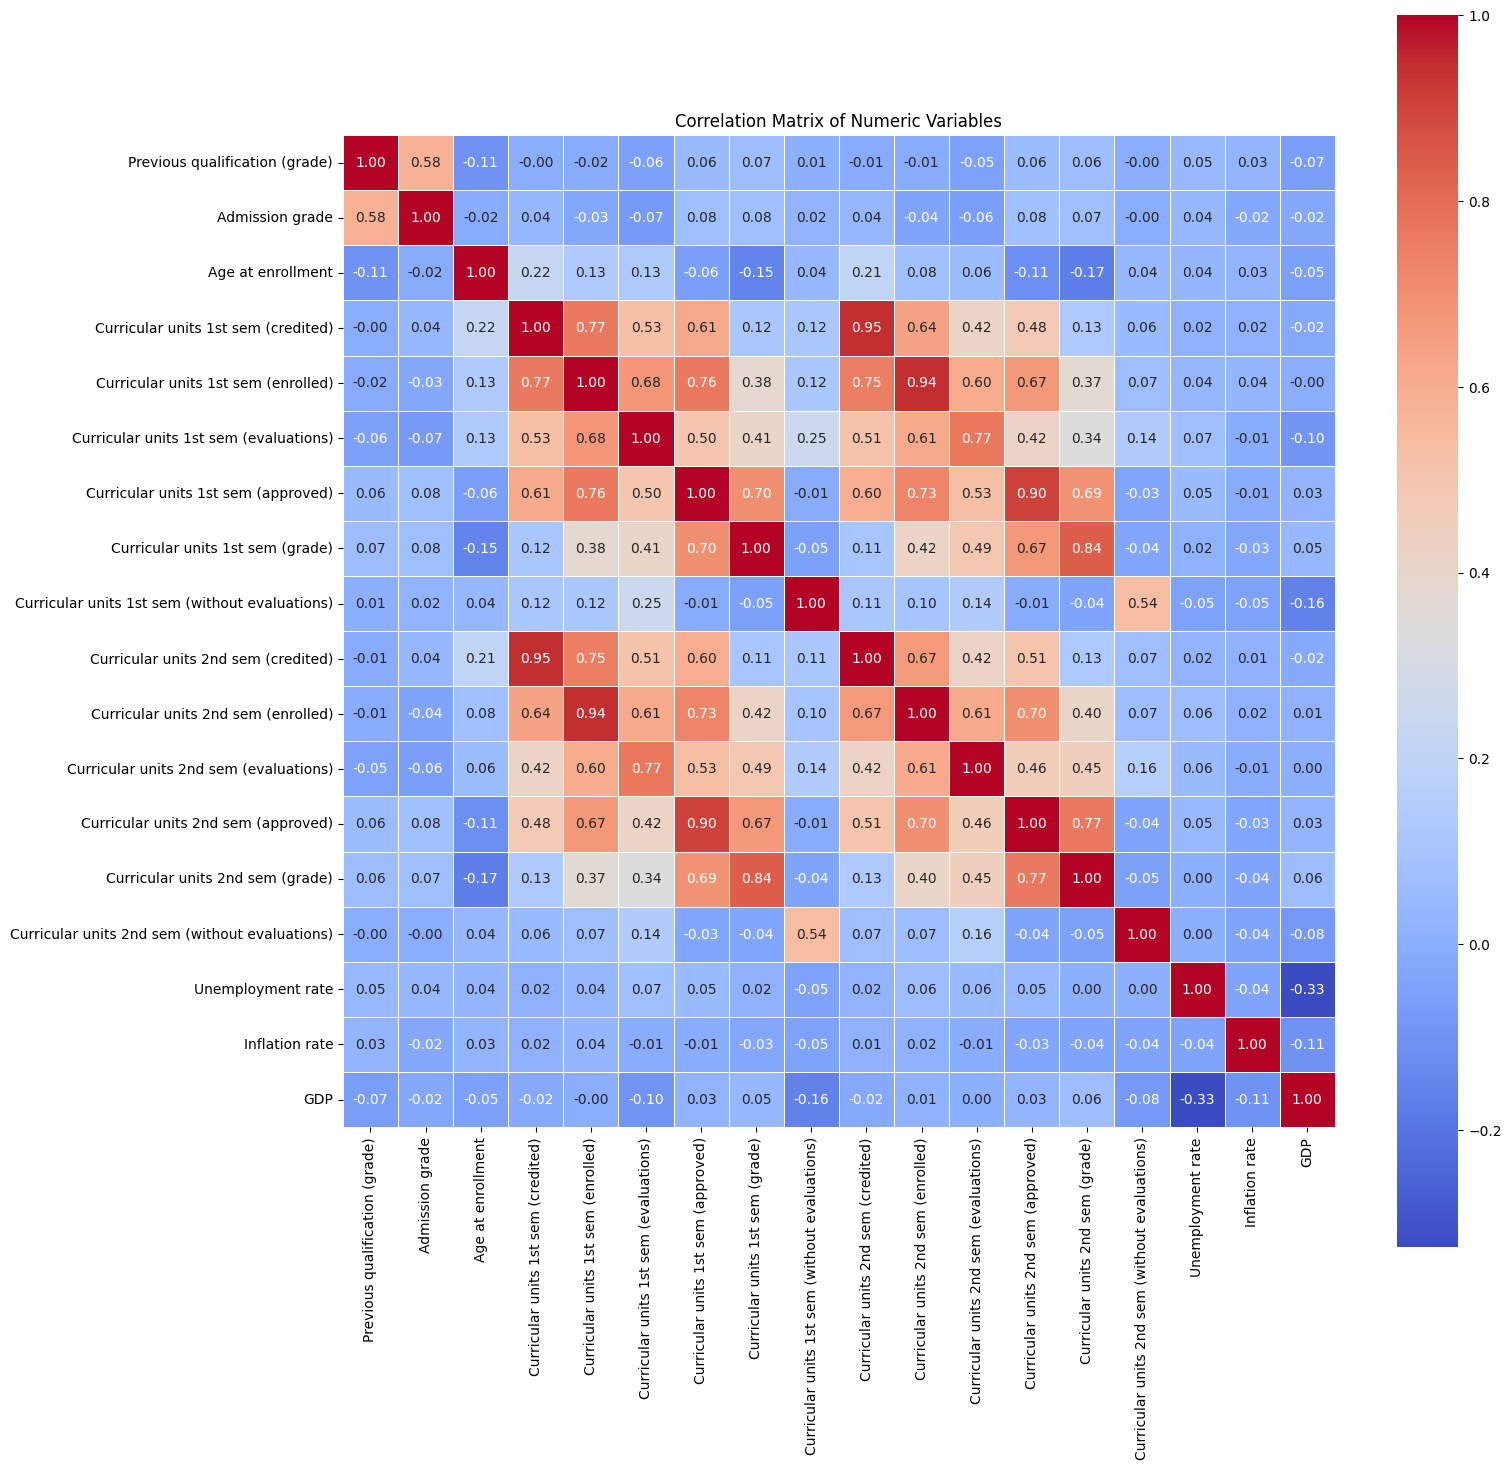

In [15]:
# Correlation Matrix

numeric_cols = X_train.select_dtypes(include='number')

corr_matrix = numeric_cols.corr()
plt.figure(figsize=(16, 16))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

**Present an overall weak correlation through all variables**

-  Curricular units 1st sem/2nd sem might have collinearity, between variable"evaluations", "approved", "grade", "credited", "enrolled". We need to delete to prevent multicollineraity, so se PCA to reduce the dimension

- The plot imply the lower the grade the easier to dropout

In [16]:
## PCA analysis

pca_vars_1st = [
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)'
]

pca_vars_2nd = [
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)'
]


def inspect_pca(df, var_list, name):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[var_list])

    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(X_scaled)

    print(f"\n===== {name} =====")
    print("Explained Variance Ratio:", pca.explained_variance_ratio_[0])
    print("Loadings:")
    print(pd.Series(pca.components_[0], index=var_list))

def fit_pca_block(df, var_list, n_components=1):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[var_list])

    pca = PCA(n_components=n_components, random_state=42)
    pca.fit(X_scaled)

    return {
        "vars": var_list,
        "scaler": scaler,
        "pca": pca
    }
pca_1st_block = fit_pca_block(X_train, pca_vars_1st)
pca_2nd_block = fit_pca_block(X_train, pca_vars_2nd)

In [17]:
## Apply PCA feature

def apply_pca_block(df, pca_block, new_name):
    df = df.copy()
    X_scaled = pca_block["scaler"].transform(df[pca_block["vars"]])
    df[new_name] = pca_block["pca"].transform(X_scaled)
    return df

## Derop column
PCA_DROP_COLS = pca_vars_1st + pca_vars_2nd

def drop_pca_original_vars(df):
    df = df.copy()
    return df.drop(columns=[c for c in PCA_DROP_COLS if c in df.columns])


In [18]:
## Fit and Transform

X_train  = apply_pca_block(X_train,  pca_1st_block, "PCA_1st_sem")
X_val = apply_pca_block(X_val, pca_1st_block, "PCA_1st_sem")
X_train  = apply_pca_block(X_train,  pca_2nd_block, "PCA_2nd_sem")
X_val = apply_pca_block(X_val, pca_2nd_block, "PCA_2nd_sem")

# drop original vars
X_train  = drop_pca_original_vars(X_train)
X_val = drop_pca_original_vars(X_val)

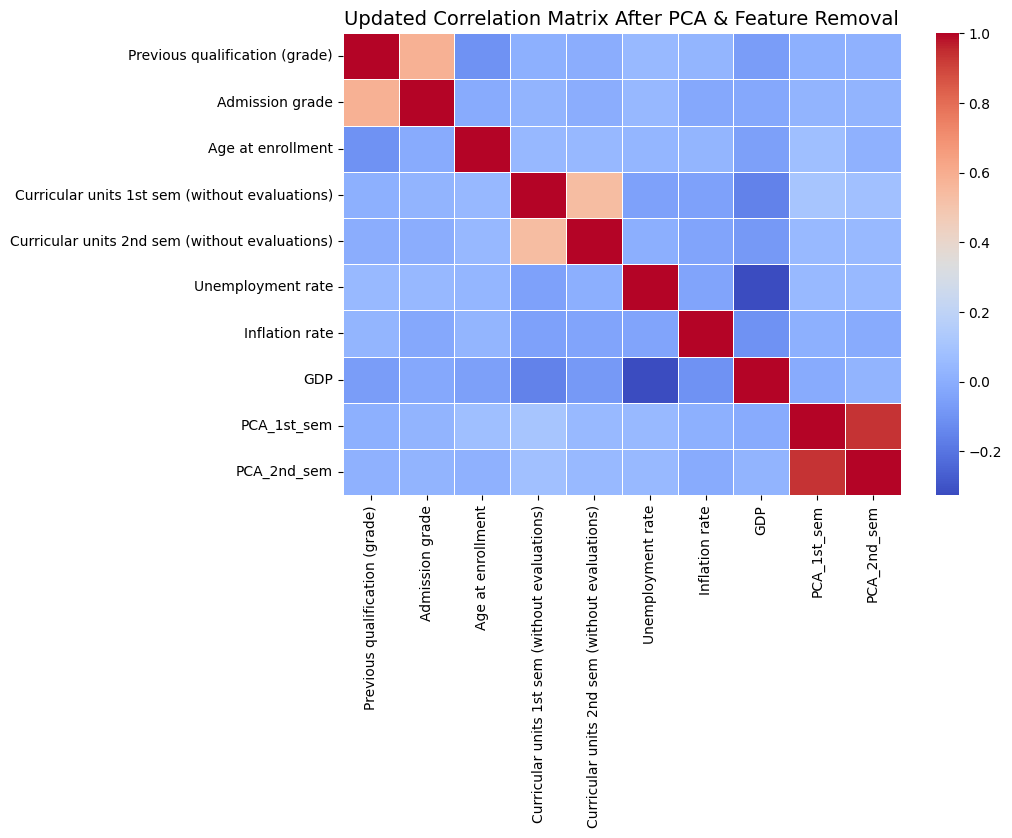

In [19]:
# Correlation heatmap after PCA
numeric_df = X_train.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(9, 6))
corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=False,
    cmap='coolwarm',
    linewidths=0.5,
    fmt='.2f',
    square=False
)
plt.title("Updated Correlation Matrix After PCA & Feature Removal", fontsize=14)
plt.show()

- Further breakdown inspection needed 

## 6. Feature Engineering

In [20]:
# Check column before processing

print(X_train.columns.tolist())

['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'PCA_1st_sem', 'PCA_2nd_sem']


#### **6.1 Numerical variable**

- 1.Kruskal–Wallis test tests whether the distributions of a numerical variable differ significantly across multiple target classes.

- 2.Add features base on distribution plot 

- 3.Intentionally do not apply feature scaling at this stage.


In [21]:
## 1. Kruskal–Wallis test

numeric_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

for col in numeric_cols:
    groups = [
        X_train[col][y_train == level]
        for level in y_train.unique()
    ]
    stat, p = kruskal(*groups)
    print(f'{col}: p-value = {p}')


## We can delete "inflation rate",as it might cause noise in the model

Previous qualification (grade): p-value = 1.3911168301425566e-11
Admission grade: p-value = 2.744193937001361e-13
Age at enrollment: p-value = 2.4406968687915766e-57
Curricular units 1st sem (without evaluations): p-value = 1.4599530270406185e-05
Curricular units 2nd sem (without evaluations): p-value = 3.4277511407148457e-06
Unemployment rate: p-value = 0.05018076827793334
Inflation rate: p-value = 0.22971524902929685
GDP: p-value = 0.005964201926327835
PCA_1st_sem: p-value = 1.0102775873329517e-95
PCA_2nd_sem: p-value = 2.03889530559882e-147


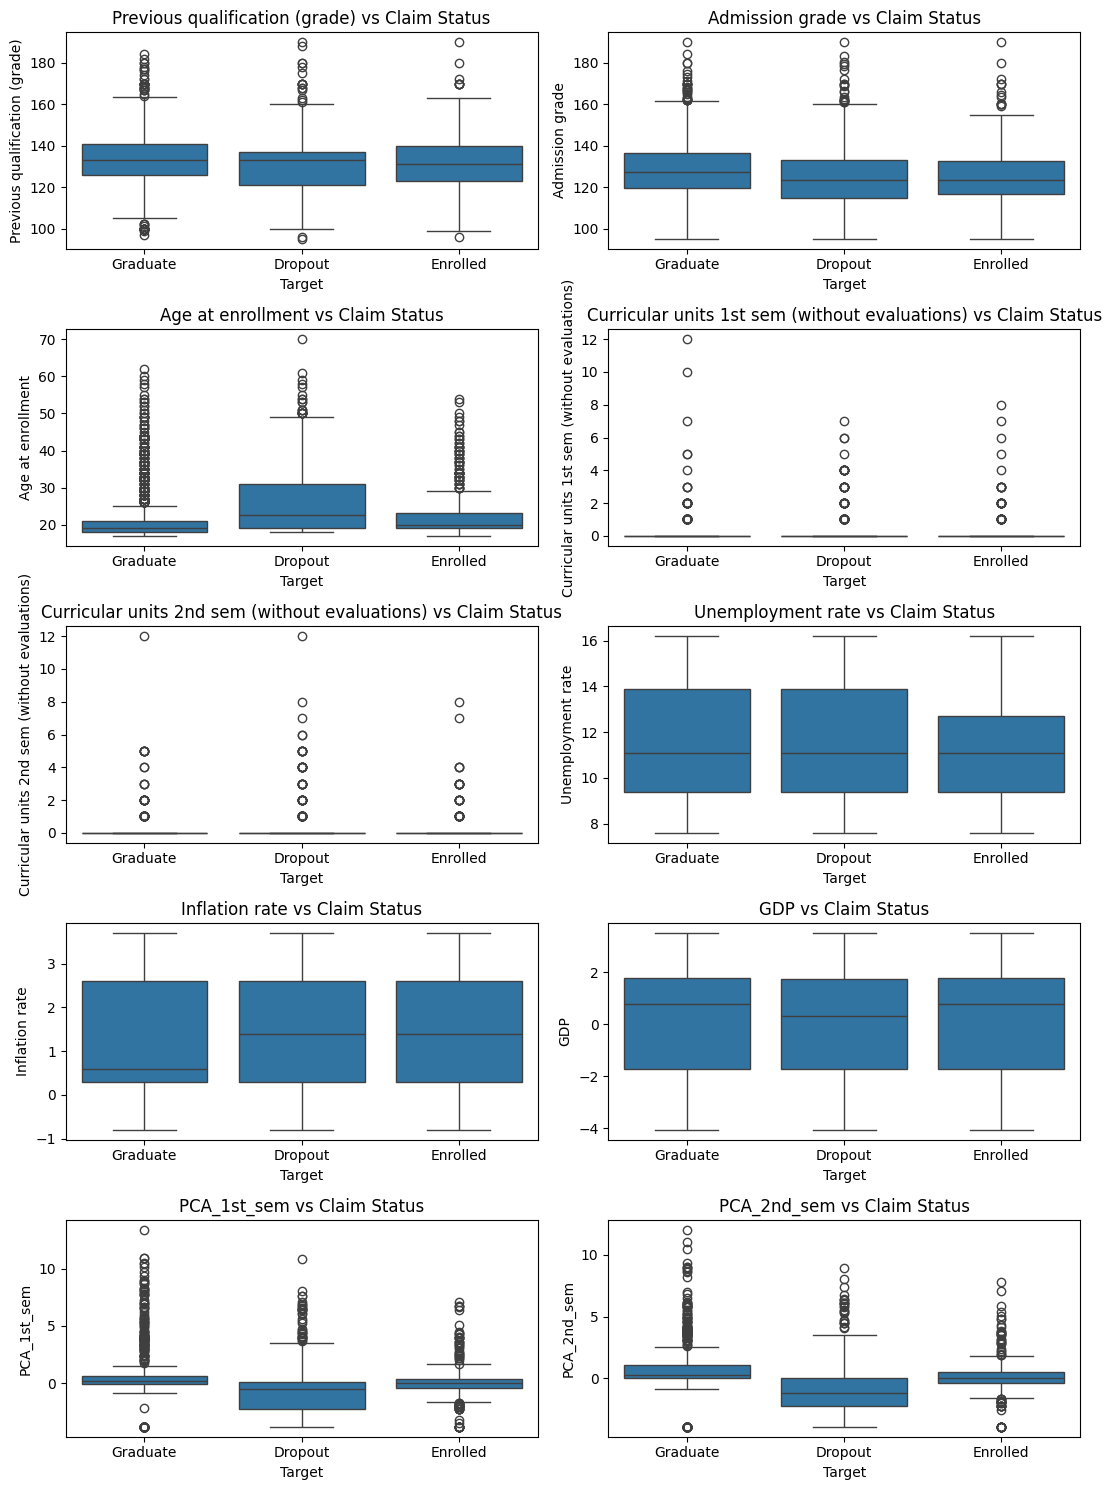

In [22]:
# Plot visualization for numerical data

numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

n_cols = 2 
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5.5, n_rows*3))
axes = axes.flatten()  

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        x=y_train,
        y=X_train[col],
        ax=axes[i]
    )
    axes[i].set_title(f'{col} vs Claim Status')


plt.tight_layout()
plt.show()


- Students’ academic performance  shows a clear separation among three groups, suggesting that early academic success is a strong predictor of final status.

- admission-related grades are moderately associated with student outcomes

- Economic features shows no power to the target

- **Grade ratio** provides a normalized measure of academic performance, reducing the effect of scale differences across educational backgrounds 

- define **is_mature_student** to create a binary variable then linear




In [23]:
## 2. Drop feature and add variable

DROP_COLS_EXTRA = [
    'Inflation rate',
]

def add_engineered_features(df):
    df = df.copy()
    epsilon = 1e-5

    # grade ratio
    if (
        "Admission grade" in df.columns and
        "Previous qualification (grade)" in df.columns
    ):
        df["grade_ratio"] = (
            df["Admission grade"] /
            (df["Previous qualification (grade)"] + epsilon)
        )


    # mature student
    if "Age at enrollment" in df.columns:
        df["is_mature_student"] = (
            df["Age at enrollment"] >= 25
    ).astype(int)


    # drop decided numeric features
    df = df.drop(columns=[c for c in DROP_COLS_EXTRA if c in df.columns])

    return df

In [24]:
### 3. DONT scaling ## For modeling purpose, we decide not to scale data

#from sklearn.preprocessing import StandardScaler

#numeric_features = X_train.select_dtypes(
    #include=['int64', 'float64']
#).columns.tolist()

#numeric_features = [
    #c for c in numeric_features
    #if X_train[c].nunique() > 2
#]


-  After comparing models trained with scaled and unscaled data,  we found that the models trained on unscaled data consistently achieved better performance across all four models. 
- Therefore, we decided not to apply feature scaling in our final modeling process.

In [25]:
## Fit and transform

# 1. feature engineering

X_train = add_engineered_features(X_train)
X_val   = add_engineered_features(X_val)

# numeric features
#numeric_features = X_train.select_dtypes(
    #include=['int64', 'float64']
#).columns.tolist()
#numeric_features = [
    #c for c in numeric_features
    #if X_train[c].nunique() > 2
#]
# 3. scaling
#scaler = StandardScaler()
#X_train[numeric_features] = scaler.fit_transform(
    #X_train[numeric_features]
#)
#X_val[numeric_features] = scaler.transform(
    #X_val[numeric_features]
#)


#### **6.2 Nominal variable**

- 1. Cramér’s V, measure of association between two categorical variables.

- 2. Add features base on distribution plot 


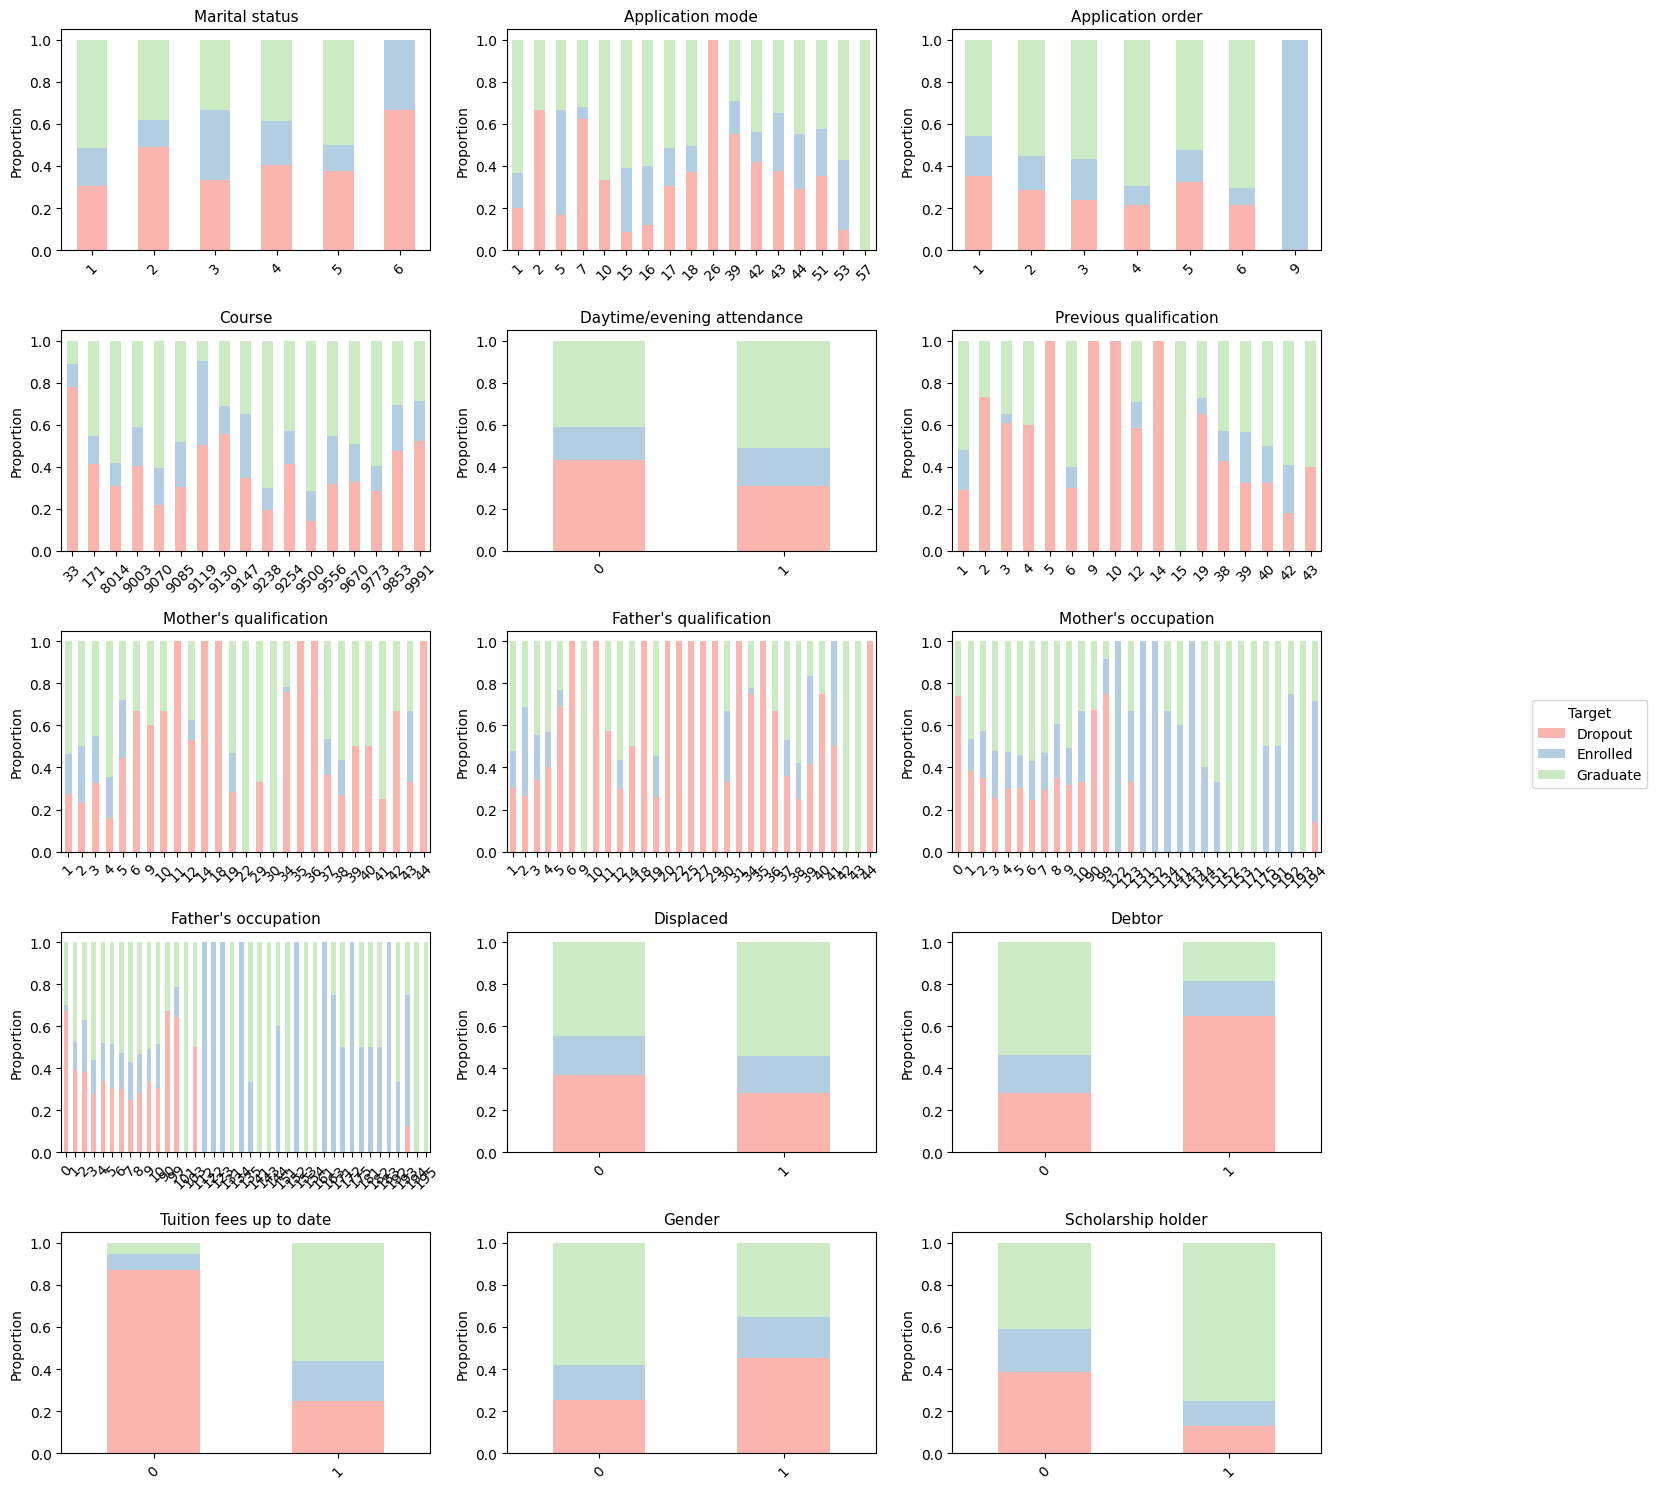

In [26]:
# Nominal variable x target variable distribition plot

nominal_cols = X_train.select_dtypes(include=['category','object']).columns.tolist()
palette = sns.color_palette("Pastel1", n_colors=y_train.nunique())

n_cols = 3 
n_rows = math.ceil(len(nominal_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols*5, n_rows*3)
)
axes = axes.flatten()

for i, col in enumerate(nominal_cols):
    table = pd.crosstab(X_train[col], y_train)
    prop_df = table.div(table.sum(axis=1), axis=0)

    prop_df.plot(
        kind='bar',
        stacked=True,
        ax=axes[i],
        color=palette,
        legend=False
    )

    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Proportion')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title='Target',
    bbox_to_anchor=(1.02, 0.5),
    loc='center left'
)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


- debtor status is strongly associated with dropout outcomes

- Fail to submit tuition fees show a slightly higher dropout proportion

- High-cardinality categorical variables exhibit noisy and unstable target distributions, limiting their interpretability in exploratory analysis.

In [27]:
## 1. Cramer's V
nominal_cols = [
    'Marital status', 
    'Application mode',
    'Application order',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder'
]
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

# train only analysis
for col in nominal_cols:
    table = pd.crosstab(X_train[col], y_train)
    print(col, "Cramer's V =", cramers_v(table))

Marital status Cramer's V = 0.08444842329664472
Application mode Cramer's V = 0.2377723901792825
Application order Cramer's V = 0.11161683488272187
Course Cramer's V = 0.25689681386181534
Daytime/evening attendance Cramer's V = 0.08248617070291951
Previous qualification Cramer's V = 0.1605449032951729
Mother's qualification Cramer's V = 0.16189044230660293
Father's qualification Cramer's V = 0.1733154965721567
Mother's occupation Cramer's V = 0.19134108958964624
Father's occupation Cramer's V = 0.19019667226054066
Displaced Cramer's V = 0.10281368146887138
Debtor Cramer's V = 0.2569020124602488
Tuition fees up to date Cramer's V = 0.4381396051972133
Gender Cramer's V = 0.2307045733516211
Scholarship holder Cramer's V = 0.30251473941313345


**Cramer's V Analysis**
- 'Application order', 'Marital status' and 'Daytime/evening attendance' show weak association with the target variable and are likely to contribute noise rather than predictive signal.

- We drop these features.



In [28]:
## 2. Drop features and new variabe

DROP_COLS_CRAMER = [
    'Application order',
    'Marital status',
    'Daytime/evening attendance'
]
def add_categorical_features(df):
    df = df.copy()

    # performance drop
    if (
        "Admission grade" in df.columns and
        "Previous qualification (grade)" in df.columns
    ):
        df["performance_drop"] = (
            df["Admission grade"] < df["Previous qualification (grade)"]
        ).astype(int)

    # age group
    if "Age at enrollment" in df.columns:
        def age_group(age):
            if age < 22:
                return "traditional"
            elif age < 25:
                return "transition"
            else:
                return "mature"

        df["age_group"] = df["Age at enrollment"].apply(age_group).astype("category")

    # drop low-association categorical vars
    df = df.drop(columns=[c for c in DROP_COLS_CRAMER if c in df.columns])

    return df


In [29]:
## Fit and Transform

X_train  = add_categorical_features(X_train)
X_val = add_categorical_features(X_val)

### 6.3 Enoded

- 1. Label Encoding for target variable, applied to convert multiple class labels into numerical format required by scikit-learn models.

- 2. Different encoding methods are applied based on the characteristics of categorical variables:
-    Target encoding for high-cardinality variable
-    One-hot encoding for low-cardinality nominal variables
-    Numerical variables are passed through unchanged



In [30]:
## 1. Label Encoded for y variable

le = LabelEncoder()
y_train_modeling = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

In [31]:
## 2. Define encoded

high_card_cat = ['Course']

one_hot_cat = [
    'Application mode',
    'Previous qualification',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'age_group',
    'is_mature_student'
]

num_cols = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Unemployment rate',
    'GDP',
    'PCA_1st_sem',
    'PCA_2nd_sem',
    'grade_ratio',
    'performance_drop'
]

target_encoder = ce.TargetEncoder(
    cols=high_card_cat,
    handle_unknown='value',
    handle_missing='value'
)

onehot_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse=False
)

encoder = ColumnTransformer(
    transformers=[
        ('target_enc', target_encoder, high_card_cat),
        ('onehot', onehot_encoder, one_hot_cat),
        ('num', 'passthrough', num_cols),
    ],
    remainder='drop'
)


In [32]:
## Fit and transform
X_train_modeling = encoder.fit_transform(X_train, y_train_modeling)
X_val_enc = encoder.transform(X_val)

/Users/ninalin/venv/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


## 7. Distribution of dependent variable

/var/folders/98/vbl85mtj76q2kgtvtsj9xmn00000gn/T/ipykernel_5081/131184434.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=student_dropout, x='Target', palette='Pastel1')


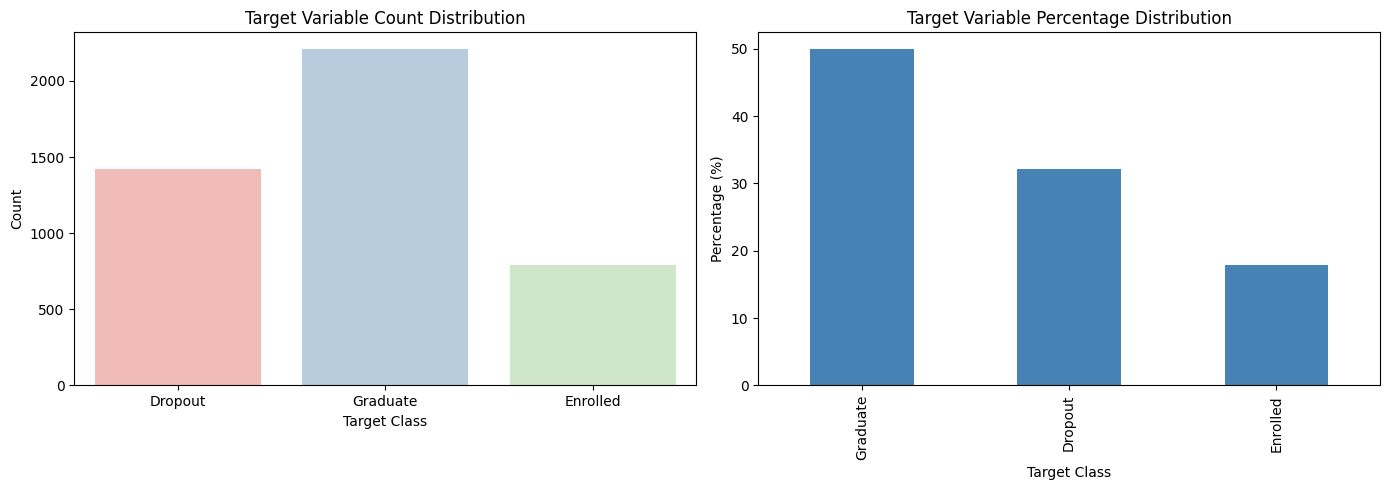

In [33]:
# Plot of dependent variable

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=student_dropout, x='Target', palette='Pastel1')
plt.title("Target Variable Count Distribution")
plt.xlabel("Target Class")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
(student_dropout['Target']
 .value_counts(normalize=True)
 .mul(100)
 .plot(kind='bar', color='steelblue'))

plt.title("Target Variable Percentage Distribution")
plt.xlabel("Target Class")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

**Target Variable Analysis**

- The distribution is clearly imbalanced, with: Graduate being the majority class and  Enrolled being the minority class

- Therefore, class imbalance handling techniques (e.g., SMOTE) are considered in later modeling stages.

## 8. Final Inspection

**Verifies that all preprocessing and feature engineering steps have been applied correctly before model training.**

**We check:**

- Feature names after encoding

- Data dimensions consistency

- Alignment between training and validation sets

In [34]:
# Final Inspection

X_train_df = pd.DataFrame(
    X_train_modeling,
    columns=encoder.get_feature_names_out()
)

print(X_train_df.head())
print(X_train_df.columns)
print("Train:", X_train_modeling.shape)
print("Val:", X_val_enc.shape)


   target_enc__Course  onehot__Application mode_1  onehot__Application mode_2  \
0            1.310345                         0.0                         0.0   
1            1.163934                         0.0                         0.0   
2            1.391607                         1.0                         0.0   
3            1.572534                         1.0                         0.0   
4            1.572534                         1.0                         0.0   

   onehot__Application mode_5  onehot__Application mode_7  \
0                         0.0                         0.0   
1                         0.0                         0.0   
2                         0.0                         0.0   
3                         0.0                         0.0   
4                         0.0                         0.0   

   onehot__Application mode_10  onehot__Application mode_15  \
0                          0.0                          0.0   
1                   

## 9. Model Training with Class Imbalance Handling

**Model Training and Hyperparameter Tuning under Class Imbalance**

- 1. Gradient Boosting + Undersampling（Pipeline）

- 2. XGBoost（Baseline + Early Stopping）

- 3. XGBoost + Sample Weight（Weighted Loss）

- 4. Random Forest + Class Weight

- 5. Model Evaluation

##### **Model Use & Interpretation**

- Given the presence of **class imbalance, mixed feature types**, and **non-linear relationships** in the dataset, we adopted a combination of tree-based ensemble models and imbalance-aware training strategies to ensure robust and fair model performance.

##### **Evaluation Metrics**

- To evaluate model performance under class imbalance properly, we focus on **precision, recall, and F1-score**, particularly for the minority class, as these metrics better reflect the model’s ability to correctly identify rare but important instances.


#### **1. Gradient Boosting + Undersampling Analysis**

- The Gradient Boosting model achieves a reasonable overall accuracy of 75%, however, a closer inspection tells performance disparities across classes. 

- In particular, the model exhibits poor recall (0.27) and F1-score (0.37) for Class 1, indicating strong bias toward the majority class. The gap between macro-averaged and weighted-averaged metrics further highlights the impact of class imbalance. 

In [35]:
## 1. Gradient Boosting + Undersampling（Pipeline）

models = {
    #"Logistic Regression": LogisticRegression(max_iter=1000),
    #"Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    #"SVM (RBF Kernel)": SVC(probability=True, random_state=42),
    #"KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}


models_under = {
    "GB + Undersampling": Pipeline([
        ('under', RandomUnderSampler(random_state=42)),
        ('model', GradientBoostingClassifier(random_state=42))
    ])
}
def evaluate_models(models_dict, X_train, y_train, X_val_enc, y_val_enc, results):
    for name, model in models_dict.items():
        print(f"\n===== Training {name} =====")
        
        model.fit(X_train, y_train)
        preds = model.predict(X_val_enc)

        acc = accuracy_score(y_val_enc, preds)
        results[name] = acc

        print(f"Accuracy: {acc:.4f}")
        print("Confusion Matrix:")
        print(confusion_matrix(y_val_enc, preds))
        print("Classification Report:")
        print(classification_report(y_val_enc, preds))

gb_under = models_under["GB + Undersampling"]

gb_under.fit(X_train_modeling, y_train_modeling)

results = {}
evaluate_models(models, X_train_modeling, y_train_modeling, X_val_enc, y_val_enc, results)



===== Training Gradient Boosting =====
Accuracy: 0.7476
Confusion Matrix:
[[126  10  35]
 [ 16  26  53]
 [ 12   8 245]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.74      0.78       171
           1       0.59      0.27      0.37        95
           2       0.74      0.92      0.82       265

    accuracy                           0.75       531
   macro avg       0.71      0.65      0.66       531
weighted avg       0.74      0.75      0.73       531



##### **2. XGBoost baseline + Early Stopping Analysis**

- XGBoost demonstrates improved performance on the minority class. However, despite this model performance improve, the model still exhibits a strong bias toward the majority class, as reflected by the persistently low minority recall. This suggests that additional imbalance-aware strategies are required.

In [36]:
# 2. XGBoost（Baseline + Early Stopping）

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(
    X_train_modeling,
    y_train_modeling,
    eval_set=[(X_val_enc, y_val_enc)],
    early_stopping_rounds=30,
    verbose=True
)

val_pred_xgb = xgb.predict(X_val_enc)

print("=== XGBoost Validation Performance ===")
print("Accuracy:", accuracy_score(y_val_enc, val_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_val_enc, val_pred_xgb))
print("\nClassification Report:\n", classification_report(y_val_enc, val_pred_xgb))


[0]	validation_0-mlogloss:1.06733
[1]	validation_0-mlogloss:1.04062
[2]	validation_0-mlogloss:1.01543
[3]	validation_0-mlogloss:0.99224
[4]	validation_0-mlogloss:0.97185
[5]	validation_0-mlogloss:0.95395
[6]	validation_0-mlogloss:0.93390
[7]	validation_0-mlogloss:0.91727
[8]	validation_0-mlogloss:0.90069
[9]	validation_0-mlogloss:0.88617
[10]	validation_0-mlogloss:0.87402
[11]	validation_0-mlogloss:0.86027
[12]	validation_0-mlogloss:0.84691
[13]	validation_0-mlogloss:0.83516
[14]	validation_0-mlogloss:0.82633
[15]	validation_0-mlogloss:0.81570
[16]	validation_0-mlogloss:0.80538
[17]	validation_0-mlogloss:0.79529
[18]	validation_0-mlogloss:0.78712


/Users/ninalin/venv/lib/python3.10/site-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[19]	validation_0-mlogloss:0.77862
[20]	validation_0-mlogloss:0.77130
[21]	validation_0-mlogloss:0.76399
[22]	validation_0-mlogloss:0.75738
[23]	validation_0-mlogloss:0.75140
[24]	validation_0-mlogloss:0.74530
[25]	validation_0-mlogloss:0.73894
[26]	validation_0-mlogloss:0.73323
[27]	validation_0-mlogloss:0.72863
[28]	validation_0-mlogloss:0.72377
[29]	validation_0-mlogloss:0.71875
[30]	validation_0-mlogloss:0.71363
[31]	validation_0-mlogloss:0.70893
[32]	validation_0-mlogloss:0.70454
[33]	validation_0-mlogloss:0.70057
[34]	validation_0-mlogloss:0.69743
[35]	validation_0-mlogloss:0.69482
[36]	validation_0-mlogloss:0.69146
[37]	validation_0-mlogloss:0.68893
[38]	validation_0-mlogloss:0.68602
[39]	validation_0-mlogloss:0.68402
[40]	validation_0-mlogloss:0.68131
[41]	validation_0-mlogloss:0.67819
[42]	validation_0-mlogloss:0.67534
[43]	validation_0-mlogloss:0.67346
[44]	validation_0-mlogloss:0.67147
[45]	validation_0-mlogloss:0.66968
[46]	validation_0-mlogloss:0.66764
[47]	validation_0-ml

#### **3. XGBoost (sample_weight balanced) Analysis**

- Class-weighted XGBoost model achieves a balanced trade-off between overall performance and minority-class sensitivity. With incorporating sample weighting, the model improves recall for the minority class while maintaining stable performance on the majority classes. This makes it well-suited for multi-class classification tasks with imbalanced data distributions.

In [37]:
## 3. XGBoost + Sample Weight（Weighted Loss）

sample_weight = compute_sample_weight(
    class_weight='balanced',
    y=y_train_modeling
)

xgb_weighted = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_weighted.fit(
    X_train_modeling,
    y_train_modeling,
    sample_weight=sample_weight
)

val_pred_xgb_w = xgb_weighted.predict(X_val_enc)

print("=== XGBoost (sample_weight balanced) ===")
print(classification_report(y_val_enc, val_pred_xgb_w))


=== XGBoost (sample_weight balanced) ===
              precision    recall  f1-score   support

           0       0.81      0.74      0.77       171
           1       0.43      0.55      0.48        95
           2       0.82      0.79      0.81       265

    accuracy                           0.73       531
   macro avg       0.69      0.69      0.69       531
weighted avg       0.75      0.73      0.74       531



##### **4. Random Forest Balanced Weight Analysis**

- Class-weighted Random Forest model achieves reasonable overall accuracy but fails to adequately identify the minority class, as evidenced by the very low recall and F1-score for class 1. It remains heavily biased toward the majority class, reduce performance on imbalanced multi-class classification tasks where minority detection is important.

In [38]:
## 4. Random Forest + Class Weight 

rf_balanced = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  
)

rf_balanced.fit(X_train_modeling, y_train_modeling)

val_pred_rf_bal = rf_balanced.predict(X_val_enc)

print("=== Random Forest (class_weight='balanced') Validation Performance ===")
print("Accuracy:", accuracy_score(y_val_enc, val_pred_rf_bal))
print("\nConfusion Matrix:\n", confusion_matrix(y_val_enc, val_pred_rf_bal))
print("\nClassification Report:\n", classification_report(y_val_enc, val_pred_rf_bal))


=== Random Forest (class_weight='balanced') Validation Performance ===
Accuracy: 0.7269303201506592

Confusion Matrix:
 [[128   6  37]
 [ 22  11  62]
 [ 11   7 247]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.75      0.77       171
           1       0.46      0.12      0.18        95
           2       0.71      0.93      0.81       265

    accuracy                           0.73       531
   macro avg       0.66      0.60      0.59       531
weighted avg       0.69      0.73      0.68       531



#### **5.Final Inspection**

- **Class-weighted XGBoost model** is selected as the final model due to its predictive performance with effective minority-class detection in an imbalanced multi-class setting.

- The model shows improved macro-averaged metrics, reflecting more balanced performance across all classes without degradation in majority-class performance. The majority class maintains stable precision and recall, confirming that gains in minority detection are not achieved at the expense of overall robustness.

- XGBoost effectively captures non-linear relationships and complex feature interactions, and the incorporation of imbalance-aware training via sample weighting directly addresses the skewed class distribution present in the data. Together, these characteristics make the selected model well-suited for achieving robust, fair in this classification task.

**Why not others?**

- Accuracy-focused models → unfair to minority class

- Undersampling → excessive information loss

- Random Forest → insufficient sensitivity

## 10. Parameter tuning

**Parameter Tuning on the Validation Set**


**The primary purpose of this evaluation stage is to:**

- 1. Optimize model hyperparameters to achieve the best trade-off 

- 2. Prevent overfitting 

- 3. Select the final model configuration based on validation performance using imbalance-aware metrics




In [39]:
# Evaluation function
from sklearn.metrics import f1_score, classification_report

def eval_on_val(model, X_val, y_val, verbose=True):
    y_pred = model.predict(X_val)
    macro_f1 = f1_score(y_val, y_pred, average="macro")
    class1_f1 = f1_score(y_val, y_pred, labels=[1], average="macro")
    
    if verbose:
        print("Macro F1:", round(macro_f1, 4))
        print("Class 1 F1:", round(class1_f1, 4))
        print(classification_report(y_val, y_pred))
        
    return macro_f1, class1_f1

In [40]:
## Parameter

param_grid = [
    # depth & child weight
    dict(max_depth=3, min_child_weight=1),
    dict(max_depth=4, min_child_weight=3),
    dict(max_depth=5, min_child_weight=3),
    dict(max_depth=6, min_child_weight=5),

    # subsampling
    dict(subsample=0.7, colsample_bytree=0.7),
    dict(subsample=0.8, colsample_bytree=0.8),
    dict(subsample=0.9, colsample_bytree=0.9),
]

In [41]:
## Model tuning

sample_weight = compute_sample_weight(
    class_weight='balanced',
    y=y_train_modeling
)

results = []

for params in param_grid:
    print("Testing params:", params)

    xgb = XGBClassifier(
        n_estimators=800,              
        learning_rate=0.05,
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        **params
    )

    xgb.fit(
        X_train_modeling,
        y_train_modeling,
        sample_weight=sample_weight
    )

    macro_f1, class1_f1 = eval_on_val(
        xgb,
        X_val_enc,
        y_val_enc,
        verbose=False
    )

    results.append({
        "params": params,
        "macro_f1": macro_f1,
        "class1_f1": class1_f1
    })

Testing params: {'max_depth': 3, 'min_child_weight': 1}
Testing params: {'max_depth': 4, 'min_child_weight': 3}
Testing params: {'max_depth': 5, 'min_child_weight': 3}
Testing params: {'max_depth': 6, 'min_child_weight': 5}
Testing params: {'subsample': 0.7, 'colsample_bytree': 0.7}
Testing params: {'subsample': 0.8, 'colsample_bytree': 0.8}
Testing params: {'subsample': 0.9, 'colsample_bytree': 0.9}


In [42]:
## Tuning Result

df_results = pd.DataFrame(results)
print(df_results.sort_values("macro_f1", ascending=False))

                                        params  macro_f1  class1_f1
0      {'max_depth': 3, 'min_child_weight': 1}  0.679034   0.477876
1      {'max_depth': 4, 'min_child_weight': 3}  0.677438   0.482412
2      {'max_depth': 5, 'min_child_weight': 3}  0.677239   0.473684
3      {'max_depth': 6, 'min_child_weight': 5}  0.676097   0.457447
5  {'subsample': 0.8, 'colsample_bytree': 0.8}  0.674427   0.427746
6  {'subsample': 0.9, 'colsample_bytree': 0.9}  0.671411   0.423529
4  {'subsample': 0.7, 'colsample_bytree': 0.7}  0.660362   0.400000


In [43]:
## Select the best parameter
best_params = (
    df_results
    .sort_values("macro_f1", ascending=False)
    .iloc[0]["params"]
)

print("Best params:", best_params)


Best params: {'max_depth': 3, 'min_child_weight': 1}


**Parameter Conclusion**

- Hyperparameter tuning on the validation set showed similar performance to the baseline model with no clear improvement in macro F1-score or minority-class performance. 

- This suggests that the original model settings were already close to optimal for the current features and data.

## 11. Test Data Preprocessing

- Prepare a unified training dataset by combining the training and validation sets.

- Apply the same preprocessing steps learned from the training data to the test set.(All transformations (NZV removal, PCA, feature engineering,
encoding) are reused from the training stage.)


In [44]:
## Combine traain and val dataset
feature_names = encoder.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train_modeling,
    columns=feature_names
)

X_val_df = pd.DataFrame(
    X_val_enc,
    columns=feature_names
)
X_trainval_df = pd.concat([X_train_df, X_val_df], axis=0)


In [45]:
## Preprocess Test data

# Assign variable type
X_test = assign_variable_types(X_test)

# nzv
X_test = drop_nzv_features(X_test)

# PCA
X_test = apply_pca_block(X_test, pca_1st_block, "PCA_1st_sem")
X_test = apply_pca_block(X_test, pca_2nd_block, "PCA_2nd_sem")
X_test = drop_pca_original_vars(X_test)

# Nominal
X_test = add_engineered_features(X_test)

# Categorical
X_test = add_categorical_features(X_test)

# Encoded
y_test_enc = le.transform(y_test)
X_test_enc = encoder.transform(X_test)


In [46]:
## Y train and val 

le_final = LabelEncoder()
le_final.fit(pd.concat([y_train, y_val], axis=0))
y_train_enc = le_final.transform(y_train)
y_val_enc   = le_final.transform(y_val)
y_trainval_enc = le_final.transform(
    pd.concat([y_train, y_val], axis=0)
)
y_test_enc  = le_final.transform(y_test)

print(le_final.classes_)
print(set(y_train_enc))
print(set(y_val_enc))
print(set(y_test_enc))

y_trainval_df = le_final.transform(
    pd.concat([y_train, y_val], axis=0)
)

['Dropout' 'Enrolled' 'Graduate']
{0, 1, 2}
{0, 1, 2}
{0, 1, 2}


In [47]:
## Inspection before testing
assert X_train_modeling.shape[1] == X_test_enc.shape[1]
assert X_test_enc.shape[0] == len(y_test_enc)

## 12. Final Model on the Test Set

In [48]:
## Test model training
best_params = {'max_depth': 3, 'min_child_weight': 1}

sample_weight_trainval = compute_sample_weight(
    class_weight='balanced',
    y=y_trainval_df
)

xgb_weighted = XGBClassifier(
    n_estimators=800,
    learning_rate=0.05,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    **best_params
)

xgb_weighted.fit(
    X_trainval_df,
    y_trainval_df,
    sample_weight=sample_weight_trainval
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=800,
              n_jobs=-1, num_class=3, num_parallel_tree=None, ...)

In [49]:
##  Model Evaluation on the Test Set

y_test_pred = xgb_weighted.predict(X_test_enc)
print("=== Test Performance ===")
print(confusion_matrix(y_test_enc, y_test_pred))
print(classification_report(y_test_enc, y_test_pred))

f1_macro = f1_score(y_test_enc, y_test_pred, average='macro')
print("Test F1 Macro:", f1_macro)
y_test_proba = xgb_weighted.predict_proba(X_test_enc)
print("Test Log Loss:", log_loss(y_test_enc, y_test_proba))


=== Test Performance ===
[[184  57  43]
 [ 24  89  46]
 [ 22 106 314]]
              precision    recall  f1-score   support

           0       0.80      0.65      0.72       284
           1       0.35      0.56      0.43       159
           2       0.78      0.71      0.74       442

    accuracy                           0.66       885
   macro avg       0.64      0.64      0.63       885
weighted avg       0.71      0.66      0.68       885

Test F1 Macro: 0.6307461993320286
Test Log Loss: 0.7404454571175247


**Final Test Set Evaluation Summary**

The final evaluation on the holdout test set confirms the generalization ability of the selected model. The XGBoost model with sample weighting achieves an overall accuracy of 0.66, a macro F1-score of 0.63, and a weighted F1-score of 0.68.

Importantly, the model presents improved performance on the minority class (Class 1), achieving a recall of 0.43, which is substantially higher than that of baseline models. This indicates that loss-level class imbalance handling effectively mitigates majority-class bias without excessively sacrificing overall performance.

Although the overall accuracy is slightly lower than some baseline models, the balanced performance across classes—reflected by the macro F1-score—suggests that the model provides a robust solution for this imbalanced multi-class classification problem.

Therefore, XGBoost with sample weighting is selected as the final model, as it offers the best trade-off between generalization performance, minority-class detection, and model stability on unseen data.

## 13. Evaluation

In [50]:
# Error analysis

error_df = pd.DataFrame({
    "true_label": y_test_enc,
    "pred_label": y_test_pred,
    "confidence": np.max(y_test_proba, axis=1)
})

error_df["error_type"] = np.where(
    error_df["true_label"] == error_df["pred_label"],
    "Correct",
    "Misclassified"
)

In [51]:
# Misclassification Analysis

def classify_error(row):
    if row["true_label"] != row["pred_label"]:
        return f"True {row['true_label']} → Pred {row['pred_label']}"
    return "Correct"

error_df["error_detail"] = error_df.apply(classify_error, axis=1)
print(error_df["error_type"].value_counts())


error_type
Correct          587
Misclassified    298
Name: count, dtype: int64


In [52]:
# Error summary

error_summary = (
    error_df[error_df["error_type"] == "Misclassified"]
    .groupby("error_detail")
    .size()
    .sort_values(ascending=False)
)

print(" Misclassification Summary ")
print(error_summary)

print(error_df[
    (error_df["error_type"] == "Misclassified") &
    (error_df["confidence"] > 0.8)
].sort_values("confidence", ascending=False).head(10))


 Misclassification Summary 
error_detail
True 2 → Pred 1    106
True 0 → Pred 1     57
True 1 → Pred 2     46
True 0 → Pred 2     43
True 1 → Pred 0     24
True 2 → Pred 0     22
dtype: int64
     true_label  pred_label  confidence     error_type     error_detail
533           2           0    0.980843  Misclassified  True 2 → Pred 0
346           1           2    0.960787  Misclassified  True 1 → Pred 2
535           1           0    0.932524  Misclassified  True 1 → Pred 0
374           1           0    0.921046  Misclassified  True 1 → Pred 0
376           0           2    0.919843  Misclassified  True 0 → Pred 2
380           0           1    0.915961  Misclassified  True 0 → Pred 1
150           0           1    0.899969  Misclassified  True 0 → Pred 1
208           0           1    0.896631  Misclassified  True 0 → Pred 1
327           0           1    0.886960  Misclassified  True 0 → Pred 1
807           0           2    0.884502  Misclassified  True 0 → Pred 2


**Misclassification Analysis**

- The misclassification patterns suggest that class imbalance and limited feature representation may disproportionately impact the intermediate group (class 1). Because class 1 sits between the other two outcomes, it is more likely to absorb ambiguous cases, which can appear as “unfair” labeling when the model is uncertain or when features do not cleanly separate groups.

- Most errors concentrate around the intermediate class (class 1). Test-set error breakdown shows that many class 2 instances are predicted as class 1 (e.g., True 2 → Pred 1 is the most frequent error), indicating substantial feature overlap between higher-risk and moderate-risk groups. 

- Overall performance and interpretation of mistakes. Out of 885 test samples, 587 were correctly classified (accuracy ≈ 66%), with ≈ 34% misclassifications. Importantly, errors are not uniformly random: they occur primarily between adjacent/closely related classes, consistent with overlapping feature distributions and a “transition” nature of class 1 rather than a simple model capacity issue.



## 14. Discussion & Limitations

In [53]:
is_mature_student = student_dropout["Age at enrollment"] >= 25

error_df["is_mature_student"] = (X_test["Age at enrollment"] >= 25).astype(int)

print(error_df.groupby("is_mature_student")["error_type"].value_counts(normalize=True))
print(error_df.groupby("is_mature_student")["confidence"].mean())


is_mature_student  error_type   
0.0                Correct          0.642857
                   Misclassified    0.357143
1.0                Correct          0.666667
                   Misclassified    0.333333
Name: proportion, dtype: float64
is_mature_student
0.0    0.691756
1.0    0.653195
Name: confidence, dtype: float32


- These findings suggest that age does not introduce a significant source of bias in the model; however, age is only a proxy attribute and other sensitive factors could not be evaluated.

**Challenges、Bias、unfair labeling、responsible use**


- The primary technical challenge arises from **severe class imbalance**, where the dropout class is underrepresented.
As a result, models optimized solely for accuracy may exhibit misleadingly strong performance while failing to correctly identify minority class instances.

- A preliminary fairness analysis was conducted by comparing model performance across age groups. The results did not indicate a substantial performance gap between mature and non-mature students. However, age was used as a proxy attribute, and other sensitive attributes were not available for analysis.

- The outcome labels are based on academic status (e.g., dropout or graduation), which may be influenced by external factors such as socioeconomic conditions or personal circumstances. As a result, the labels may not fully represent students’ academic potential.

- This model is intended to support early intervention and academic assistance rather than to make high-stakes decisions. Predictions should be interpreted as risk indicators and used in conjunction with human judgment.

## 15. Conclusion

In this project, a multi-class classification approach was applied to predict
students’ academic outcomes using a real-world higher education dataset.

Several machine learning models were explored and compared, including Gradient
Boosting, Random Forest, and XGBoost. Special attention was given to handling
class imbalance through undersampling, class weighting, and sample weighting
strategies. The experimental results indicate that **XGBoost with imbalance-aware techniques**, achieved
balanced performance across all outcome classes.

Future work could include incorporating additional features, applying more
advanced imbalance handling techniques, or exploring interpretable models to
better understand the factors influencing student outcomes.


## 16. Bibliography

 https://dl.acm.org/doi/10.1145/2939672.2939785

 https://christophm.github.io/interpretable-ml-book/

 https://dl.acm.org/doi/10.1145/3287560.3287596

 https://ieeexplore.ieee.org/abstract/document/5128907
